# Build DiD Monthly Panel — China WTO Accession

This notebook constructs a Difference-in-Differences (DiD) panel to estimate the impact of China's WTO entry (January 2002) on U.S. imports from China. Treatment is based on pre-policy NTR-gap exposure at the HS8 product level.

## Segment 1: Load & Inspect Data

We start from `panel_hts10_monthly.csv` — a pre-cleaned monthly trade panel at the HTS10 product level. This file was built from raw USITC DataWeb imports data. We also need `tar_val.dta`, which contains tariff/NTR-gap data from Pierce & Schott (2016, AER).

**Why these files?**
- The trade panel gives us monthly import values and quantities by product (HTS10 = 10-digit Harmonized Tariff Schedule code)
- The tariff file gives us the "NTR gap" — the difference between the high (non-NTR) tariff and the low (NTR) tariff for each product. Products with a bigger gap had more to gain from permanent NTR status, making them more "treated" by China's WTO entry.

In [2]:
import pandas as pd
import numpy as np
import os

# File paths (relative to notebook location in Code/)
panel_path = "../transformed_data/panel_hts10_monthly.csv"
tariff_path = "../transformed_data/data_files_aer_2013/tar_val.dta"

# Verify files exist
for name, path in [("Trade panel", panel_path), ("Tariff file", tariff_path)]:
    exists = os.path.exists(path)
    size = f"{os.path.getsize(path) / 1e6:.1f} MB" if exists else "NOT FOUND"
    print(f"{name}: {path} — {size}")

Trade panel: ../transformed_data/panel_hts10_monthly.csv — 119.2 MB
Tariff file: ../transformed_data/data_files_aer_2013/tar_val.dta — 5.9 MB


### Load the trade panel and inspect its structure

We need to understand the columns before doing any transformations. Key things to look for:
- What does each row represent?
- What are the product code and date columns?
- What are the value/quantity columns?
- Are there any obvious data type issues (e.g., product codes read as numbers, losing leading zeros)?

In [3]:
# Load trade panel
panel = pd.read_csv(panel_path, dtype={"hts10": str})

print(f"Shape: {panel.shape[0]:,} rows × {panel.shape[1]} columns")
print(f"\nColumns:\n{list(panel.columns)}")
print(f"\nData types:\n{panel.dtypes}")
print(f"\nFirst 5 rows:")
panel.head()

Shape: 1,251,312 rows × 11 columns

Columns:
['Country', 'Year', 'Month', 'hts10', 'customs_value', 'first_unit_qty', 'date', 'unit_value', 'ln_customs_value', 'ln_first_unit_qty', 'ln_unit_value']

Data types:
Country                  str
Year                   int64
Month                    str
hts10                    str
customs_value          int64
first_unit_qty         int64
date                     str
unit_value           float64
ln_customs_value     float64
ln_first_unit_qty    float64
ln_unit_value        float64
dtype: object

First 5 rows:


,Country,Year,Month,hts10,customs_value,first_unit_qty,date,unit_value,ln_customs_value,ln_first_unit_qty,ln_unit_value
0,China,1996,January,0101110020,0,0,1996-01-01,NaN,0.000000,0.00000,NaN
1,China,1996,February,0101110020,0,0,1996-02-01,NaN,0.000000,0.00000,NaN
2,China,1996,March,0101110020,3150,6,1996-03-01,525.0,8.055475,1.94591,6.263398
3,China,1996,April,0101110020,0,0,1996-04-01,NaN,0.000000,0.00000,NaN
4,China,1996,May,0101110020,0,0,1996-05-01,NaN,0.000000,0.00000,NaN


In [4]:
# Check: are HTS10 codes proper 10-digit strings?
print("Sample hts10 values:", panel["hts10"].head(10).tolist())
print(f"\nAll 10 digits? {(panel['hts10'].str.len() == 10).all()}")
print(f"Any NaN hts10? {panel['hts10'].isna().sum()}")

# Check countries present
print(f"\nUnique countries: {panel['Country'].nunique()}")
print(f"Country values: {panel['Country'].unique()[:10]}")

# Check date range
print(f"\nDate range: {panel['date'].min()} to {panel['date'].max()}")
print(f"Unique dates: {panel['date'].nunique()}")

Sample hts10 values: ['0101110020', '0101110020', '0101110020', '0101110020', '0101110020', '0101110020', '0101110020', '0101110020', '0101110020', '0101110020']

All 10 digits? True
Any NaN hts10? 0

Unique countries: 1
Country values: <StringArray>
['China']
Length: 1, dtype: str

Date range: 1996-01-01 to 2005-12-01
Unique dates: 120


## Segment 2: Clean & Prepare for HS8 Aggregation

Our goal is to go from HTS10 (10-digit product codes) to HS8 (8-digit). Why?
- The tariff data (`tar_val.dta`) is at the HS8 level
- Multiple HTS10 codes map to the same HS8 (the last 2 digits are US-specific detail)
- We need to match granularity for the DiD merge

Steps:
1. Parse the `date` column to datetime
2. Drop the 11 known problematic HTS10 codes (products that switched quantity units over time — mixing units would corrupt our quantity analysis)
3. Create the `hs8` column (first 8 digits of `hts10`)

In [5]:
# Parse date to datetime
panel["date"] = pd.to_datetime(panel["date"])

# Drop known HTS10 codes with quantity-description switches
# These products changed how they measure quantity (e.g., from kg to units),
# so summing their quantities over time would be meaningless
problem_hts10 = [
    "2607000020", "2711290060", "6111206050", "6111305050", "6111905050",
    "7115900530", "7115900590", "7115903000", "7115904000", "7115906000",
    "9001300000"
]

rows_before = len(panel)
panel = panel[~panel["hts10"].isin(problem_hts10)].copy()
rows_after = len(panel)

print(f"Dropped {rows_before - rows_after:,} rows from {len(problem_hts10)} problematic HTS10 codes")
print(f"Remaining: {rows_after:,} rows")

# Create HS8 (first 8 digits)
panel["hs8"] = panel["hts10"].str[:8]

print(f"\nUnique HTS10 codes: {panel['hts10'].nunique():,}")
print(f"Unique HS8 codes:  {panel['hs8'].nunique():,}")
print(f"(Multiple HTS10s can map to one HS8)")

Dropped 720 rows from 11 problematic HTS10 codes
Remaining: 1,250,592 rows

Unique HTS10 codes: 16,276
Unique HS8 codes:  9,711
(Multiple HTS10s can map to one HS8)


In [6]:
# Quick sanity check: how many HTS10 codes per HS8?
hts10_per_hs8 = panel.groupby("hs8")["hts10"].nunique()
print("HTS10 codes per HS8:")
print(hts10_per_hs8.describe())
print(f"\nExample — HS8 '01011100' contains HTS10s: {panel[panel['hs8'] == '01011100']['hts10'].unique()}")

HTS10 codes per HS8:
count    9711.000000
mean        1.676037
std         1.751822
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        35.000000
Name: hts10, dtype: float64

Example — HS8 '01011100' contains HTS10s: <StringArray>
['0101110020']
Length: 1, dtype: str


## Segment 3: Aggregate to HS8-Month Panel

**Teaching guide — General Task 3 / Pseudocode STEP C**

Multiple HTS10 codes can map to one HS8. We aggregate up to (hs8, date) because our tariff treatment variable is at the HS8 level.

Rules:
- **Customs value**: always sum across HTS10s within (hs8, date)
- **Quantity**: sum across HTS10s (unit-switching codes were already dropped in Segment 2)
- **Unit value**: recompute as customs_value / quantity after aggregation

Note: The R `.qmd` also tracks `unit_consistent` (whether all HTS10s in an HS8-month share the same quantity unit). Our input panel lacks the `quantity_description` column, so we skip that check — the 11 problematic codes were already removed.

In [7]:
# Aggregate HTS10 → HS8 monthly panel
panel_hs8 = (
    panel
    .groupby(["hs8", "date"], as_index=False)
    .agg(
        customs_value=("customs_value", "sum"),
        first_unit_qty_hs8=("first_unit_qty", "sum"),
        n_hts10_in_hs8=("hts10", "nunique"),
        year=("Year", "first")
    )
)

# Recompute unit_value at HS8 level
panel_hs8["unit_value"] = np.where(
    panel_hs8["first_unit_qty_hs8"] > 0,
    panel_hs8["customs_value"] / panel_hs8["first_unit_qty_hs8"],
    np.nan
)

print(f"HS8-month panel: {len(panel_hs8):,} rows")
print(f"Unique HS8 codes: {panel_hs8['hs8'].nunique():,}")
print(f"Date range: {panel_hs8['date'].min()} to {panel_hs8['date'].max()}")

HS8-month panel: 813,528 rows
Unique HS8 codes: 9,711
Date range: 1996-01-01 00:00:00 to 2005-12-01 00:00:00


In [8]:
# Duplicate-key check: every (hs8, date) should appear exactly once
dup_check = panel_hs8.groupby(["hs8", "date"]).size()
n_dups = (dup_check > 1).sum()
print(f"Duplicate (hs8, date) keys: {n_dups}")

# Summary stats
print(f"\ncustoms_value summary:")
print(panel_hs8["customs_value"].describe())

print(f"\nunit_value summary (non-null):")
print(panel_hs8["unit_value"].dropna().describe())

print(f"\nRows with zero customs_value: {(panel_hs8['customs_value'] == 0).sum():,}")
print(f"Rows with missing unit_value: {panel_hs8['unit_value'].isna().sum():,}")

Duplicate (hs8, date) keys: 0

customs_value summary:
count    8.135280e+05
mean     1.453287e+06
std      1.072014e+07
min      0.000000e+00
25%      0.000000e+00
50%      2.781350e+04
75%      2.998600e+05
max      1.082094e+09
Name: customs_value, dtype: float64

unit_value summary (non-null):
count    4.520240e+05
mean     1.063799e+03
std      7.279234e+04
min      2.435986e-04
25%      1.709372e+00
50%      5.372309e+00
75%      2.974466e+01
max      3.273581e+07
Name: unit_value, dtype: float64

Rows with zero customs_value: 269,057
Rows with missing unit_value: 361,504


## Segment 4: Construct Treatment Variable (NTR Gap)

**Teaching guide — General Task 4 / Pseudocode STEP D**

The NTR gap (`spread`) measures how much a product's tariff would rise if China lost Normal Trade Relations status. Products with larger gaps had more at stake when Congress voted annually on China's trade status.

We use 1999 as the pre-period year (before WTO negotiations intensified) and compute a trade-weighted average gap at the HS8 level. This becomes our treatment intensity variable: `gap_pre`.

In [9]:
# Load tariff data
tar = pd.read_stata(tariff_path)

print(f"tar_val.dta shape: {tar.shape}")
print(f"Columns: {list(tar.columns)}")
print(f"\nFirst 5 rows:")
tar.head()

tar_val.dta shape: (133807, 7)
Columns: ['hs8num', 'hs8', 'ntr_rate', 'nonntr_rate', 'spread', 'v', 'year']

First 5 rows:


,hs8num,hs8,ntr_rate,nonntr_rate,spread,v,year
0,1011100,01011100,0.0,0.0,0.0,4523119.0,1989.0
1,1011100,01011100,0.0,0.0,0.0,4768635.0,1990.0
2,1011100,01011100,0.0,0.0,0.0,1766068.0,1991.0
3,1011100,01011100,0.0,0.0,0.0,2912166.0,1992.0
4,1011100,01011100,0.0,0.0,0.0,3236751.0,1993.0


In [10]:
# Filter to 1999, keep relevant columns
tar_1999 = tar[tar["year"] == 1999][["hs8", "spread", "v"]].copy()

# Clean HS8 code: ensure 8-digit string with leading zeros
tar_1999["hs8"] = tar_1999["hs8"].astype(str).str.replace(r"[^0-9]", "", regex=True)
tar_1999["hs8"] = tar_1999["hs8"].str.zfill(8).str[:8]

# Drop rows with missing gap or invalid codes
tar_1999 = tar_1999.dropna(subset=["spread"])
tar_1999 = tar_1999[tar_1999["hs8"].str.len() == 8]

print(f"Tariff rows for 1999: {len(tar_1999):,}")
print(f"Unique HS8 in tariff data: {tar_1999['hs8'].nunique():,}")
print(f"\nspread (NTR gap) summary:")
print(tar_1999["spread"].describe())

Tariff rows for 1999: 9,997
Unique HS8 in tariff data: 9,997

spread (NTR gap) summary:
count    9997.000000
mean        0.316807
std         0.230394
min         0.000000
25%         0.172000
50%         0.311000
75%         0.423967
max         4.840000
Name: spread, dtype: float64


In [11]:
# Collapse to HS8: weighted mean of spread, weighted by trade value (v)
def weighted_mean_gap(df):
    """Compute weighted mean of spread by v; fall back to simple mean if no valid weights."""
    valid = df.dropna(subset=["v"])
    valid = valid[valid["v"] > 0]
    if len(valid) > 0:
        return np.average(valid["spread"], weights=valid["v"])
    else:
        return df["spread"].mean()

gap_pre_hs8 = (
    tar_1999
    .groupby("hs8")
    .apply(weighted_mean_gap, include_groups=False)
    .reset_index(name="gap_pre")
)

print(f"HS8 codes with gap_pre: {len(gap_pre_hs8):,}")
print(f"\ngap_pre summary:")
print(gap_pre_hs8["gap_pre"].describe())

HS8 codes with gap_pre: 9,997

gap_pre summary:
count    9997.000000
mean        0.316807
std         0.230394
min         0.000000
25%         0.172000
50%         0.311000
75%         0.423967
max         4.840000
Name: gap_pre, dtype: float64


In [12]:
# Merge gap_pre onto the HS8-month trade panel (left join — keep all trade rows)
did_panel = panel_hs8.merge(gap_pre_hs8, on="hs8", how="left")

n_matched = did_panel["gap_pre"].notna().sum()
n_total = len(did_panel)
print(f"Rows with gap_pre: {n_matched:,} / {n_total:,} ({n_matched/n_total:.1%})")
print(f"HS8 codes matched: {did_panel.loc[did_panel['gap_pre'].notna(), 'hs8'].nunique():,}")
print(f"HS8 codes unmatched: {did_panel.loc[did_panel['gap_pre'].isna(), 'hs8'].nunique():,}")

Rows with gap_pre: 766,524 / 813,528 (94.2%)
HS8 codes matched: 8,621
HS8 codes unmatched: 1,090


## Segment 5: Create DiD Variables

**Teaching guide — General Task 5 / Pseudocode STEPS E & F**

We now construct the core DiD structure:
- `post`: =1 after China's WTO entry (Jan 2002)
- `highgap`: =1 if product's NTR gap is above the median (more "treated" by permanent NTR)
- `treated`: interaction term (highgap × post) — this is our coefficient of interest
- `event_time`: months relative to Jan 2002 (for event study plots)
- Log-transformed outcomes for the regression

In [13]:
# Policy date and median gap
policy_date = pd.Timestamp("2002-01-01")
median_gap = did_panel["gap_pre"].median()
print(f"Policy date: {policy_date.date()}")
print(f"Median gap_pre: {median_gap:.6f}")

# DiD indicators
did_panel["post"] = (did_panel["date"] >= policy_date).astype(int)
did_panel["highgap"] = np.where(
    did_panel["gap_pre"].notna(),
    (did_panel["gap_pre"] >= median_gap).astype(int),
    np.nan
)
did_panel["treated"] = np.where(
    did_panel["highgap"].notna(),
    did_panel["highgap"] * did_panel["post"],
    np.nan
)

# Event time: months relative to Jan 2002
did_panel["event_time"] = (
    (did_panel["date"].dt.year - policy_date.year) * 12
    + (did_panel["date"].dt.month - policy_date.month)
)

# Log-transformed outcomes
did_panel["ln_customs_value"] = np.log1p(did_panel["customs_value"])
did_panel["ln_first_unit_qty"] = np.where(
    did_panel["first_unit_qty_hs8"].notna(),
    np.log1p(did_panel["first_unit_qty_hs8"]),
    np.nan
)
did_panel["ln_unit_value"] = np.where(
    (did_panel["unit_value"].notna()) & (did_panel["unit_value"] > 0),
    np.log(did_panel["unit_value"]),
    np.nan
)

# Sort
did_panel = did_panel.sort_values(["hs8", "date"]).reset_index(drop=True)

print(f"\nPanel shape: {did_panel.shape}")
print(f"Columns: {list(did_panel.columns)}")

Policy date: 2002-01-01
Median gap_pre: 0.349000

Panel shape: (813528, 15)
Columns: ['hs8', 'date', 'customs_value', 'first_unit_qty_hs8', 'n_hts10_in_hs8', 'year', 'unit_value', 'gap_pre', 'post', 'highgap', 'treated', 'event_time', 'ln_customs_value', 'ln_first_unit_qty', 'ln_unit_value']


In [14]:
# Verify DiD variables
print("=== DiD Variable Checks ===\n")

print(f"post distribution:\n{did_panel['post'].value_counts().sort_index()}\n")
print(f"highgap distribution (excl NaN):\n{did_panel['highgap'].value_counts().sort_index()}\n")
print(f"highgap NaN count: {did_panel['highgap'].isna().sum():,}\n")
print(f"treated distribution (excl NaN):\n{did_panel['treated'].value_counts().sort_index()}\n")

print(f"event_time range: {did_panel['event_time'].min()} to {did_panel['event_time'].max()}")
print(f"  (should be -72 to 47 for Jan 1996 to Dec 2005)\n")

print(f"gap_pre summary:")
print(did_panel["gap_pre"].describe())

=== DiD Variable Checks ===

post distribution:
post
0    450204
1    363324
Name: count, dtype: int64

highgap distribution (excl NaN):
highgap
0.0    383172
1.0    383352
Name: count, dtype: int64

highgap NaN count: 47,004

treated distribution (excl NaN):
treated
0.0    602148
1.0    164376
Name: count, dtype: int64

event_time range: -72 to 47
  (should be -72 to 47 for Jan 1996 to Dec 2005)

gap_pre summary:
count    766524.000000
mean          0.350092
std           0.221391
min           0.000000
25%           0.213000
50%           0.349000
75%           0.450000
max           3.067611
Name: gap_pre, dtype: float64


In [15]:
# Save the final DiD panel
output_path = "../transformed_data/did_panel_monthly.csv"
did_panel.to_csv(output_path, index=False)
print(f"Saved to {output_path}")
print(f"Final panel: {len(did_panel):,} rows × {did_panel.shape[1]} columns")

# Quick look at final dataset
did_panel.head(10)

Saved to ../transformed_data/did_panel_monthly.csv
Final panel: 813,528 rows × 15 columns


,hs8,date,customs_value,first_unit_qty_hs8,n_hts10_in_hs8,year,unit_value,gap_pre,post,highgap,treated,event_time,ln_customs_value,ln_first_unit_qty,ln_unit_value
0,01011100,1996-01-01,0,0,1,1996,NaN,0.0,0,0.0,0.0,-72,0.000000,0.00000,NaN
1,01011100,1996-02-01,0,0,1,1996,NaN,0.0,0,0.0,0.0,-71,0.000000,0.00000,NaN
2,01011100,1996-03-01,3150,6,1,1996,525.0,0.0,0,0.0,0.0,-70,8.055475,1.94591,6.263398
3,01011100,1996-04-01,0,0,1,1996,NaN,0.0,0,0.0,0.0,-69,0.000000,0.00000,NaN
4,01011100,1996-05-01,0,0,1,1996,NaN,0.0,0,0.0,0.0,-68,0.000000,0.00000,NaN
5,01011100,1996-06-01,0,0,1,1996,NaN,0.0,0,0.0,0.0,-67,0.000000,0.00000,NaN
6,01011100,1996-07-01,0,0,1,1996,NaN,0.0,0,0.0,0.0,-66,0.000000,0.00000,NaN
7,01011100,1996-08-01,0,0,1,1996,NaN,0.0,0,0.0,0.0,-65,0.000000,0.00000,NaN
8,01011100,1996-09-01,0,0,1,1996,NaN,0.0,0,0.0,0.0,-64,0.000000,0.00000,NaN
9,01011100,1996-10-01,0,0,1,1996,NaN,0.0,0,0.0,0.0,-63,0.000000,0.00000,NaN


## Segment 6: Diagnostics & Estimation

**Teaching guide — Section 7 (Diagnostics) + General Task 6 / Pseudocode (Estimation)**

First we run the minimum diagnostics checklist, then estimate the DiD ladder:
- **m1**: No fixed effects (pooled OLS)
- **m2**: Product (HS8) fixed effects
- **m3**: Date (month) fixed effects  
- **m4**: Product + Date fixed effects (preferred specification)

All models cluster standard errors at the product (HS8) level. The coefficient of interest is `highgap × post` — the differential change in imports for high-gap vs low-gap products after China's WTO entry.

In [16]:
# === Minimum Diagnostics Checklist (Section 7 of teaching guide) ===

print("=== Diagnostics Checklist ===\n")

# 1. No duplicate keys
dup_check = did_panel.groupby(["hs8", "date"]).size()
print(f"1. Duplicate (hs8, date) keys: {(dup_check > 1).sum()}")

# 2. Date range
print(f"2. Date range: {did_panel['date'].min().date()} to {did_panel['date'].max().date()}")

# 3. Number of unique HS8
print(f"3. Unique HS8 codes: {did_panel['hs8'].nunique():,}")

# 4. gap_pre summary
print(f"\n4. gap_pre summary:")
print(did_panel["gap_pre"].describe())

# 5. customs_value summary
print(f"\n5. customs_value summary:")
print(did_panel["customs_value"].describe())

# 6. unit_value summary (non-null)
print(f"\n6. unit_value summary (non-null):")
print(did_panel["unit_value"].dropna().describe())

=== Diagnostics Checklist ===

1. Duplicate (hs8, date) keys: 0
2. Date range: 1996-01-01 to 2005-12-01
3. Unique HS8 codes: 9,711

4. gap_pre summary:
count    766524.000000
mean          0.350092
std           0.221391
min           0.000000
25%           0.213000
50%           0.349000
75%           0.450000
max           3.067611
Name: gap_pre, dtype: float64

5. customs_value summary:
count    8.135280e+05
mean     1.453287e+06
std      1.072014e+07
min      0.000000e+00
25%      0.000000e+00
50%      2.781350e+04
75%      2.998600e+05
max      1.082094e+09
Name: customs_value, dtype: float64

6. unit_value summary (non-null):
count    4.520240e+05
mean     1.063799e+03
std      7.279234e+04
min      2.435986e-04
25%      1.709372e+00
50%      5.372309e+00
75%      2.974466e+01
max      3.273581e+07
Name: unit_value, dtype: float64


In [ ]:
import pyfixest as pf

# Fix: match Vincent's coding — treat missing gap_pre as highgap = 0
# This keeps all 813,528 observations in the regression
did_panel["highgap"] = np.where(
    did_panel["gap_pre"].notna() & (did_panel["gap_pre"] >= median_gap),
    1,
    0
).astype(int)

did_panel["treated"] = did_panel["highgap"] * did_panel["post"]

print(f"highgap distribution:\n{did_panel['highgap'].value_counts().sort_index()}")
print(f"\nNo more NaN in highgap: {did_panel['highgap'].isna().sum()}")

# Re-run the ladder
m1 = pf.feols("ln_customs_value ~ highgap * post", data=did_panel, vcov={"CRV1": "hs8"})
m2 = pf.feols("ln_customs_value ~ highgap * post | hs8", data=did_panel, vcov={"CRV1": "hs8"})
m3 = pf.feols("ln_customs_value ~ highgap * post | date", data=did_panel, vcov={"CRV1": "hs8"})
m4 = pf.feols("ln_customs_value ~ highgap * post | hs8 + date", data=did_panel, vcov={"CRV1": "hs8"})

pf.etable([m1, m2, m3, m4])

highgap distribution:
highgap
0    430176
1    383352
Name: count, dtype: int64

No more NaN in highgap: 0


/Users/aryangoel/Desktop/w26-causal-inference-economics/.venv/lib/python3.12/site-packages/pyfixest/estimation/feols_.py:2847: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['highgap'].
            
  warnings.warn(
/Users/aryangoel/Desktop/w26-causal-inference-economics/.venv/lib/python3.12/site-packages/pyfixest/estimation/feols_.py:2847: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['post'].
            
  warnings.warn(
/Users/aryangoel/Desktop/w26-causal-inference-economics/.venv/lib/python3.12/site-packages/pyfixest/estimation/feols_.py:2847: UserWarning: 
            2 variables dropped due to multicollinearity.
            The following variables are dropped: ['highgap', 'post'].
            
  warnings.warn(


GT(_tbl_data=  level_0               level_1                      0                      1  \
0    coef               highgap  1.191*** <br> (0.109)                          
1    coef                  post  0.938*** <br> (0.057)  1.926*** <br> (0.042)   
2    coef          highgap:post   0.227** <br> (0.077)    0.132* <br> (0.059)   
3    coef             Intercept  6.924*** <br> (0.075)                          
4      fe                  date                      -                      -   
5      fe                   hs8                      -                      x   
6   stats          Observations                 813528                 813528   
7   stats             S.E. type                by: hs8                by: hs8   
8   stats         R<sup>2</sup>                  0.019                  0.630   
9   stats  R<sup>2</sup> Within                      -                  0.062   

                       2                    3  
0  1.191*** <br> (0.110)                       
1                                              
2   0.230** <br> (0.078)  0.126* <br> (0.059)  
3                                              
4                      x                    x  
5                      -                    x  
6                 813528               813528  
7                by: hs8              by: hs8  
8                  0.024                0.642  
9                  0.012                0.000  , _body=<great_tables._gt_data.Body object at 0x31faa8f20>, _boxhead=Boxhead([ColInfo(var='level_0', type=<ColInfoTypeEnum.row_group: 3>, column_label='level_0', column_align='center', column_width=None), ColInfo(var='level_1', type=<ColInfoTypeEnum.stub: 2>, column_label='level_1', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None), ColInfo(var='3', type=<ColInfoTypeEnum.default: 1>, column_label='(4)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x326f80d40>, _spanners=Spanners([SpannerInfo(spanner_id='ln_customs_value', spanner_level=1, spanner_label='ln_customs_value', spanner_units=None, spanner_pattern=None, vars=['0', '1', '2', '3'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x326f81f70>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x326f80800>, _source_notes=['Significance levels: * p < 0.05, ** p < 0.01, *** p < 0.001. Format of coefficient cell:\nCoefficient \n (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x326f82f90>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_

In [19]:
# Re-save with corrected highgap coding
did_panel.to_csv("../transformed_data/did_panel_monthly.csv", index=False)
print("Re-saved did_panel_monthly.csv with corrected highgap coding")

Re-saved did_panel_monthly.csv with corrected highgap coding


## Segment 7: Event Study

**Teaching guide — Pseudocode (Estimation), event study section**

The event study estimates a separate treatment effect for each month relative to China's WTO entry (Jan 2002). This lets us:
1. **Check pre-trends**: coefficients before Jan 2002 should be near zero (no differential trend between high-gap and low-gap products before the policy)
2. **See the treatment dynamics**: how quickly did imports respond after WTO entry?

The reference period is `event_time = -1` (December 2001, the month before WTO entry). All coefficients are relative to this month.

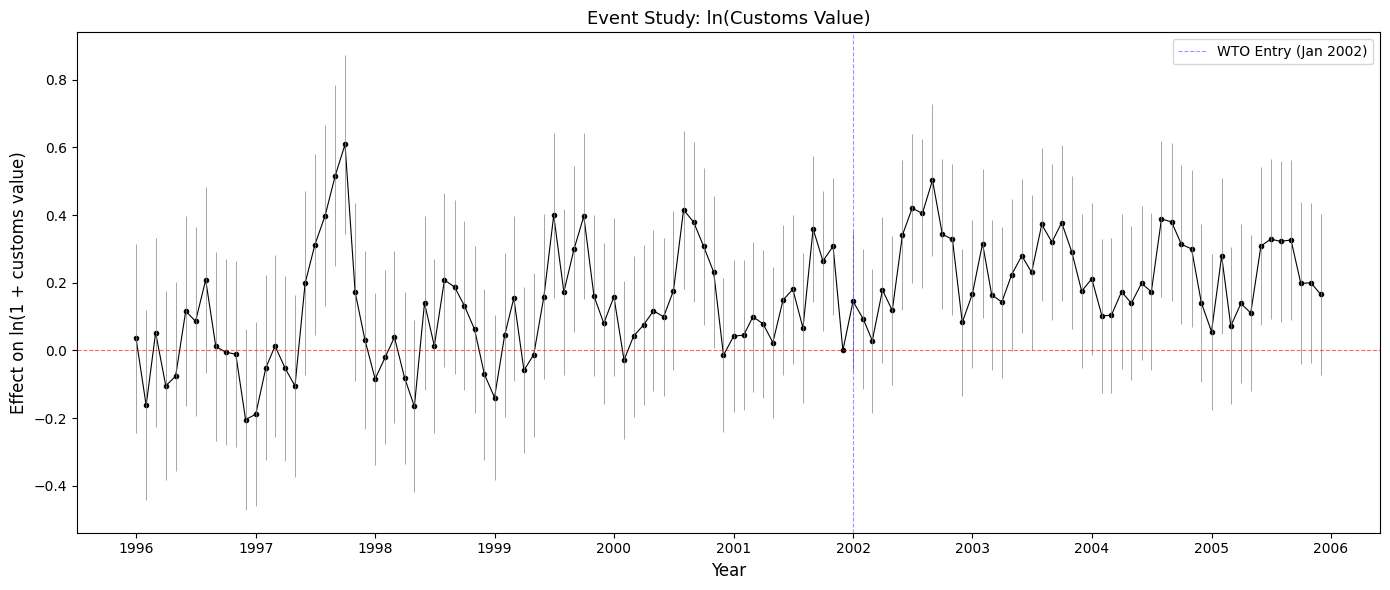

Saved event study plot


In [23]:
import matplotlib.pyplot as plt

# Run event study
es = pf.feols(
    "ln_customs_value ~ i(event_time, highgap, ref=-1) | hs8 + date",
    data=did_panel,
    vcov={"CRV1": "hs8"}
)

# Extract coefficients — 'Coefficient' is the index
coef_df = es.tidy().copy()
coef_df["coef_name"] = coef_df.index

# Extract event_time integer from coefficient names like "...[-72]:highgap"
coef_df["event_time"] = coef_df["coef_name"].str.extract(r'\[([-\d]+)\]').astype(int)
coef_df = coef_df.sort_values("event_time")

# Add reference period (event_time = -1) as zero
ref_row = pd.DataFrame({
    "event_time": [-1],
    "Estimate": [0.0],
    "Std. Error": [0.0],
    "2.5%": [0.0],
    "97.5%": [0.0]
})
coef_df = pd.concat([coef_df, ref_row], ignore_index=True).sort_values("event_time")

# Convert event_time to approximate calendar dates
coef_df["cal_date"] = pd.to_datetime("2002-01-01") + coef_df["event_time"].apply(
    lambda m: pd.DateOffset(months=int(m))
)

# Plot — matching Vincent's style
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(coef_df["cal_date"], coef_df["Estimate"],
        color="black", marker="o", markersize=3, linewidth=0.8)
ax.vlines(coef_df["cal_date"], coef_df["2.5%"], coef_df["97.5%"],
          color="gray", linewidth=0.7, alpha=0.7)
ax.axhline(y=0, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axvline(x=pd.Timestamp("2002-01-01"), color="blue", linestyle="--",
           linewidth=0.8, alpha=0.4, label="WTO Entry (Jan 2002)")

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Effect on ln(1 + customs value)", fontsize=12)
ax.set_title("Event Study: ln(Customs Value)", fontsize=13)
ax.legend()

fig.tight_layout()
fig.savefig("../notes/event_study_ln_customs_value_python.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved event study plot")